# Model Experiment — Prophet

## Section 1 — Imports & Setup

In [1]:
!pip install prophet -q

import pandas as pd
import numpy as np
from prophet import Prophet
import wandb
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import pickle
import os

from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', 100)
np.random.seed(42)

Mounted at /content/drive


## Section 2 — Load Cleaned Data

In [2]:
path = '/content/drive/MyDrive/ML-final/data/processed/'
df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])
print("Loaded:", df.shape)

Loaded: (421570, 16)


## Section 3 — Wandb Login

In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abali22 (gormo22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Section 4 — Confirm Clean Data (`Prophet_Cleaning`)

In [4]:
run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_Cleaning", job_type="preprocessing")
wandb.log({"rows": df.shape[0], "cols": df.shape[1], "missing": int(df.isnull().sum().sum())})
wandb.finish()

cols,▁
missing,▁
rows,▁
cols,16
missing,0
rows,421570


## Section 5 — Build Holiday Table

In [5]:
super_bowl = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
labor_day = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
thanksgiving = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
christmas = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

def make_holiday_df(name, dates, lower, upper):
    return pd.DataFrame({'holiday': name, 'ds': dates, 'lower_window': lower, 'upper_window': upper})

prophet_holidays = pd.concat([
    make_holiday_df('SuperBowl', super_bowl, -7, 0),
    make_holiday_df('LaborDay', labor_day, -7, 0),
    make_holiday_df('Thanksgiving', thanksgiving, -14, 7),
    make_holiday_df('Christmas', christmas, -21, 7),
]).reset_index(drop=True)

print(prophet_holidays)

         holiday         ds  lower_window  upper_window
0      SuperBowl 2010-02-12            -7             0
1      SuperBowl 2011-02-11            -7             0
2      SuperBowl 2012-02-10            -7             0
3      SuperBowl 2013-02-08            -7             0
4       LaborDay 2010-09-10            -7             0
5       LaborDay 2011-09-09            -7             0
6       LaborDay 2012-09-07            -7             0
7       LaborDay 2013-09-06            -7             0
8   Thanksgiving 2010-11-26           -14             7
9   Thanksgiving 2011-11-25           -14             7
10  Thanksgiving 2012-11-23           -14             7
11  Thanksgiving 2013-11-29           -14             7
12     Christmas 2010-12-31           -21             7
13     Christmas 2011-12-30           -21             7
14     Christmas 2012-12-28           -21             7
15     Christmas 2013-12-27           -21             7


## Section 6 — Time-Based Split

In [6]:
cutoff_date = pd.Timestamp('2011-10-01')
print(f"Cutoff: {cutoff_date.date()}")

Cutoff: 2011-10-01


## Section 7 — Hyperparameter Search (Sampled, `Prophet_Hyperparameter_Search`)

In [7]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

HPO_SAMPLE_SIZE = 30
hpo_series = (df.groupby(['Store', 'Dept'])['Weekly_Sales'].sum()
              .sort_values(ascending=False).head(HPO_SAMPLE_SIZE).reset_index()[['Store', 'Dept']])

import random
random.seed(42)

param_space = {
    "changepoint_prior_scale": [0.01, 0.05, 0.1, 0.5],
    "seasonality_prior_scale": [1.0, 5.0, 10.0],
    "holidays_prior_scale": [1.0, 5.0, 10.0],
}

N_TRIALS = 15
seen = set()
param_grid = []
while len(param_grid) < N_TRIALS:
    combo = {k: random.choice(v) for k, v in param_space.items()}
    key = tuple(sorted(combo.items()))
    if key in seen:
        continue
    seen.add(key)
    param_grid.append(combo)

run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_Hyperparameter_Search", job_type="hyperparameter-search")

hpo_results = []
for trial_i, params in enumerate(param_grid):
    trial_preds, trial_actuals, trial_holiday = [], [], []
    for _, row in hpo_series.iterrows():
        store, dept = row['Store'], row['Dept']
        series = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
        series_p = series[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
        train_s = series_p[series_p['ds'] <= cutoff_date]
        val_s = series_p[series_p['ds'] > cutoff_date]
        if len(train_s) < 30 or len(val_s) == 0:
            continue
        try:
            m = Prophet(holidays=prophet_holidays, yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False, **params)
            m.fit(train_s)
            forecast = m.predict(val_s[['ds']])
            preds = np.clip(forecast['yhat'].values, a_min=0, a_max=None)
        except Exception:
            continue
        trial_preds.append(preds)
        trial_actuals.append(val_s['y'].values)
        val_hol = df[(df['Store'] == store) & (df['Dept'] == dept) & (df['Date'] > cutoff_date)]['IsHoliday'].values
        trial_holiday.append(val_hol)

    if not trial_actuals:
        continue
    trial_wmae = wmae(np.concatenate(trial_actuals), np.concatenate(trial_preds), np.concatenate(trial_holiday))
    hpo_results.append({**params, "wmae": trial_wmae})
    print(f"Trial {trial_i+1}/{N_TRIALS}: {params} -> wmae={trial_wmae:.2f}")

hpo_df = pd.DataFrame(hpo_results).sort_values("wmae").reset_index(drop=True)
print("\nTop 5:")
print(hpo_df.head())

best_prophet_params = hpo_df.iloc[0].drop("wmae").to_dict()
print("\nBest params:", best_prophet_params)

wandb.log({"hpo_results": wandb.Table(dataframe=hpo_df)})
wandb.config.update({"best_params": best_prophet_params, "n_trials": N_TRIALS})
wandb.finish()

Trial 1/15: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 10.0} -> wmae=12188.43
Trial 2/15: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 1.0} -> wmae=11561.83
Trial 3/15: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 1.0} -> wmae=10408.95
Trial 4/15: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 5.0} -> wmae=12308.70
Trial 5/15: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 1.0} -> wmae=10120.63
Trial 6/15: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 10.0} -> wmae=12811.58
Trial 7/15: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 1.0} -> wmae=10112.94
Trial 8/15: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 5.0} -> wmae=14190.07
Trial

## Section 8 — Feature Engineering Experiment: Baseline vs Holidays vs Regressor (`Prophet_Feature_Engineering`)

In [8]:
FE_SAMPLE_SIZE = 30
fe_series = (df.groupby(['Store', 'Dept'])['Weekly_Sales'].sum()
             .sort_values(ascending=False).head(FE_SAMPLE_SIZE).reset_index()[['Store', 'Dept']])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
if 'Total_Markdown' not in df.columns:
    df['Total_Markdown'] = df[markdown_cols].sum(axis=1)

def fit_and_score(train_df, val_df, use_holidays, use_regressor):
    kwargs = dict(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, **best_prophet_params)
    if use_holidays:
        kwargs['holidays'] = prophet_holidays
    m = Prophet(**kwargs)
    if use_regressor:
        m.add_regressor('Total_Markdown')
    m.fit(train_df)
    future_cols = ['ds'] + (['Total_Markdown'] if use_regressor else [])
    forecast = m.predict(val_df[future_cols])
    return np.clip(forecast['yhat'].values, a_min=0, a_max=None)

run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_Feature_Engineering", job_type="feature-engineering")

fe_preds = {'baseline': [], 'holidays': [], 'holidays_regressor': []}
fe_actuals, fe_holiday_flags = [], []

for _, row in tqdm(fe_series.iterrows(), total=len(fe_series), desc="Feature engineering experiment"):
    store, dept = row['Store'], row['Dept']
    series = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
    series_p = series[['Date', 'Weekly_Sales', 'Total_Markdown']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    train_s = series_p[series_p['ds'] <= cutoff_date]
    val_s = series_p[series_p['ds'] > cutoff_date].copy()
    if len(train_s) < 30 or len(val_s) == 0:
        continue
    val_holiday = df[(df['Store'] == store) & (df['Dept'] == dept) & (df['Date'] > cutoff_date)]['IsHoliday'].values
    try:
        preds_base = fit_and_score(train_s, val_s, use_holidays=False, use_regressor=False)
        preds_hol = fit_and_score(train_s, val_s, use_holidays=True, use_regressor=False)
        preds_reg = fit_and_score(train_s, val_s, use_holidays=True, use_regressor=True)
    except Exception:
        continue
    fe_preds['baseline'].append(preds_base)
    fe_preds['holidays'].append(preds_hol)
    fe_preds['holidays_regressor'].append(preds_reg)
    fe_actuals.append(val_s['y'].values)
    fe_holiday_flags.append(val_holiday)

y_true_flat = np.concatenate(fe_actuals)
holiday_flat = np.concatenate(fe_holiday_flags)

fe_summary = []
for name, preds_list in fe_preds.items():
    preds_flat = np.concatenate(preds_list)
    score = wmae(y_true_flat, preds_flat, holiday_flat)
    fe_summary.append({'config': name, 'wmae': score})
    print(f"{name:22s}: WMAE = {score:.2f}")

fe_summary_df = pd.DataFrame(fe_summary)
wandb.log({"FE_Comparison": wandb.Table(dataframe=fe_summary_df)})
wandb.finish()

Feature engineering experiment: 100%|██████████| 30/30 [01:46<00:00,  3.55s/it]


baseline              : WMAE = 13732.72
holidays              : WMAE = 10112.94
holidays_regressor    : WMAE = 10112.94


## Section 9 — Walk-Forward Cross-Validation (`Prophet_CV`)

In [9]:
CV_SAMPLE_SIZE = 30
cv_series = (df.groupby(['Store', 'Dept'])['Weekly_Sales'].sum()
             .sort_values(ascending=False).head(CV_SAMPLE_SIZE).reset_index()[['Store', 'Dept']])

fold_cutoffs = [pd.Timestamp('2011-07-01'), pd.Timestamp('2011-10-01'), pd.Timestamp('2012-01-01')]

run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_CV", job_type="cross-validation")

cv_results = []
for fold_i, fold_cutoff in enumerate(fold_cutoffs):
    fold_preds, fold_actuals, fold_holiday = [], [], []
    for _, row in cv_series.iterrows():
        store, dept = row['Store'], row['Dept']
        series = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
        series_p = series[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
        train_s = series_p[series_p['ds'] <= fold_cutoff]
        val_s = series_p[series_p['ds'] > fold_cutoff].copy()
        if len(train_s) < 30 or len(val_s) == 0:
            continue
        val_hol = df[(df['Store'] == store) & (df['Dept'] == dept) & (df['Date'] > fold_cutoff)]['IsHoliday'].values
        try:
            m = Prophet(holidays=prophet_holidays, yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False, **best_prophet_params)
            m.fit(train_s)
            forecast = m.predict(val_s[['ds']])
            preds = np.clip(forecast['yhat'].values, a_min=0, a_max=None)
        except Exception:
            continue
        fold_preds.append(preds)
        fold_actuals.append(val_s['y'].values)
        fold_holiday.append(val_hol)
    if not fold_actuals:
        continue
    fold_wmae = wmae(np.concatenate(fold_actuals), np.concatenate(fold_preds), np.concatenate(fold_holiday))
    cv_results.append({"fold": fold_i + 1, "cutoff": str(fold_cutoff.date()), "wmae": fold_wmae})
    print(f"Fold {fold_i+1} ({fold_cutoff.date()}): WMAE={fold_wmae:.2f}")

cv_df = pd.DataFrame(cv_results)
mean_wmae, std_wmae = cv_df['wmae'].mean(), cv_df['wmae'].std()
print(f"\nCV WMAE: {mean_wmae:.2f} +/- {std_wmae:.2f}")

wandb.log({"cv_results": wandb.Table(dataframe=cv_df)})
wandb.log({"cv_mean_wmae": mean_wmae, "cv_std_wmae": std_wmae})
wandb.finish()

Fold 1 (2011-07-01): WMAE=10900.86
Fold 2 (2011-10-01): WMAE=10112.94
Fold 3 (2012-01-01): WMAE=9684.39

CV WMAE: 10232.73 +/- 617.02


cv_mean_wmae,▁
cv_std_wmae,▁
cv_mean_wmae,10232.7292
cv_std_wmae,617.01849


## Section 10 — Select Series To Process

In [10]:
all_series = df[['Store', 'Dept']].drop_duplicates().reset_index(drop=True)
MAX_SERIES = None  # None = all series (full-scale, ~30-90 min)
series_to_process = all_series if MAX_SERIES is None else all_series.head(MAX_SERIES)
print(f"Processing {len(series_to_process)} series")

Processing 3331 series


## Section 11 — Train & Validate Per Series (`Prophet_Training`)

In [11]:
run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_Training", job_type="training")

fitted_models = {}
val_predictions, val_actuals, val_holiday_flags, val_series_ids = [], [], [], []
errors = []

for _, row in tqdm(series_to_process.iterrows(), total=len(series_to_process), desc="Training Prophet per series"):
    store, dept = row['Store'], row['Dept']
    series = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
    series_p = series[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    train_s = series_p[series_p['ds'] <= cutoff_date]
    val_s = series_p[series_p['ds'] > cutoff_date]
    if len(train_s) < 30 or len(val_s) == 0:
        continue
    try:
        m = Prophet(holidays=prophet_holidays, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False, **best_prophet_params)
        m.fit(train_s)
        forecast = m.predict(val_s[['ds']])
        preds = np.clip(forecast['yhat'].values, a_min=0, a_max=None)
        fitted_models[(store, dept)] = m
        val_predictions.append(preds)
        val_actuals.append(val_s['y'].values)
        val_hol = df[(df['Store'] == store) & (df['Dept'] == dept) & (df['Date'] > cutoff_date)]['IsHoliday'].values
        val_holiday_flags.append(val_hol)
        val_series_ids.append((store, dept))
    except Exception as e:
        errors.append((store, dept, str(e)))

print(f"\nFitted {len(fitted_models)} models, {len(errors)} errors")
wandb.log({"n_fitted": len(fitted_models), "n_errors": len(errors)})
wandb.finish()

Training Prophet per series: 100%|██████████| 3331/3331 [1:10:37<00:00,  1.27s/it]


Fitted 2965 models, 0 errors


n_errors,▁
n_fitted,▁
n_errors,0
n_fitted,2965


## Section 12 — Evaluate Results

In [12]:
y_true_all = np.concatenate(val_actuals)
y_pred_all = np.concatenate(val_predictions)
holiday_all = np.concatenate(val_holiday_flags)

overall_wmae = wmae(y_true_all, y_pred_all, holiday_all)
overall_mae = np.mean(np.abs(y_true_all - y_pred_all))

print(f"Overall Prophet WMAE across {len(fitted_models)} series: {overall_wmae:.2f}")
print(f"Overall Prophet MAE: {overall_mae:.2f}")

run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_Evaluation", job_type="evaluation")
wandb.log({"val_wmae_overall": overall_wmae, "val_mae_overall": overall_mae,
           "n_series_evaluated": len(fitted_models)})
wandb.finish()

Overall Prophet WMAE across 2965 series: 2110.64
Overall Prophet MAE: 2035.74


n_series_evaluated,▁
val_mae_overall,▁
val_wmae_overall,▁
n_series_evaluated,2965
val_mae_overall,2035.74372
val_wmae_overall,2110.64405


## Section 13 — Visualize Example Forecasts (`Prophet_Components`)

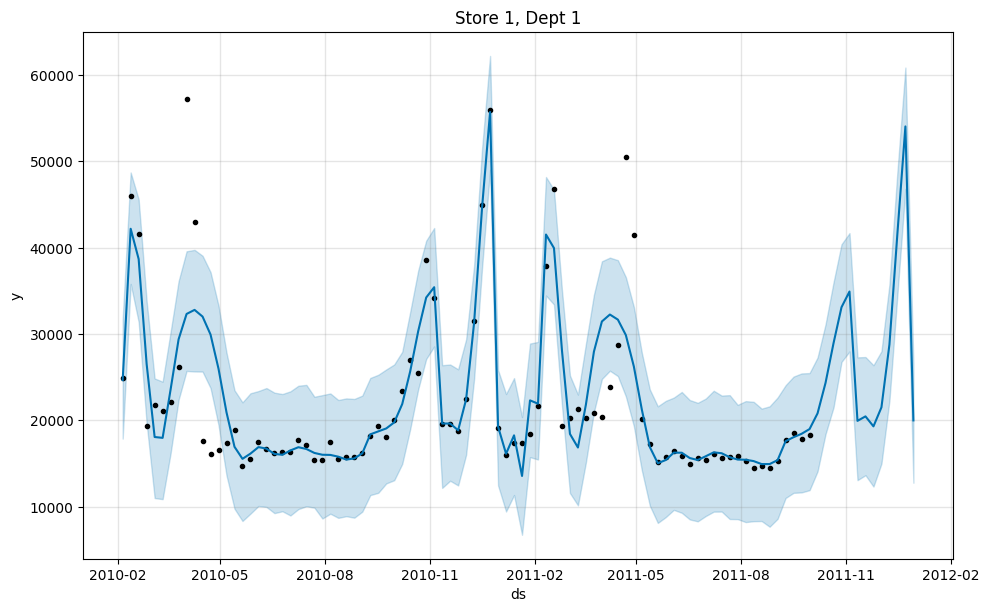

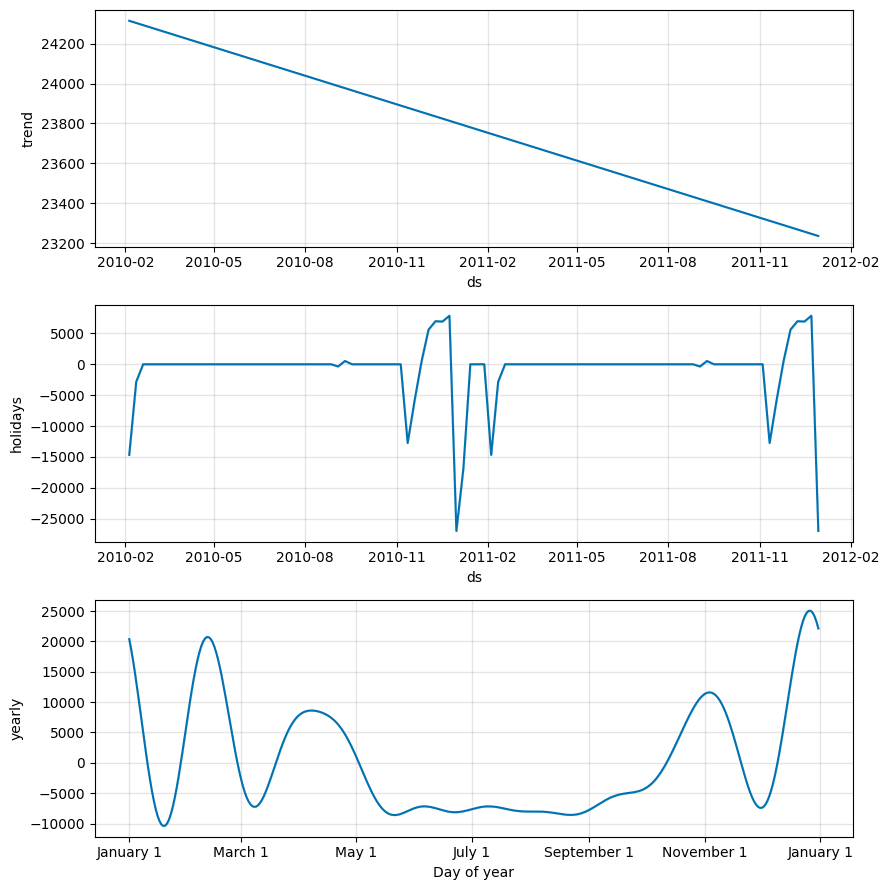

In [13]:
run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_Components", job_type="analysis")

sample_key = val_series_ids[0]
sample_model = fitted_models[sample_key]
sample_series = df[(df['Store'] == sample_key[0]) & (df['Dept'] == sample_key[1])].sort_values('Date')
sample_p = sample_series[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
future = sample_model.make_future_dataframe(periods=13, freq='W-FRI')
forecast = sample_model.predict(future)

fig1 = sample_model.plot(forecast)
plt.title(f"Store {sample_key[0]}, Dept {sample_key[1]}")
wandb.log({"Example_Forecast": wandb.Image(fig1)})
plt.show()

fig2 = sample_model.plot_components(forecast)
wandb.log({"Example_Components": wandb.Image(fig2)})
plt.show()

wandb.finish()

## Section 14 — Full Kaggle Submission (optional)

In [14]:
raw_path = '/content/drive/MyDrive/ML-final/data/raw/'
test_raw = pd.read_csv(raw_path + 'test.csv')
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

dept_avg_map = df.groupby('Dept')['Weekly_Sales'].mean().to_dict()
overall_mean = df['Weekly_Sales'].mean()

run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_Kaggle_Submission", job_type="submission")

submission_rows = []
for (store, dept), test_group in tqdm(test_raw.groupby(['Store', 'Dept']), desc="Full Kaggle submission"):
    series = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
    series_p = series[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    test_group = test_group.sort_values('Date')
    preds = None
    if len(series_p) >= 30:
        try:
            m = Prophet(holidays=prophet_holidays, yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False, **best_prophet_params)
            m.fit(series_p)
            forecast = m.predict(test_group[['Date']].rename(columns={'Date': 'ds'}))
            preds = np.clip(forecast['yhat'].values, a_min=0, a_max=None)
        except Exception:
            preds = None
    if preds is None:
        preds = np.full(len(test_group), dept_avg_map.get(dept, overall_mean))
    for date, pred in zip(test_group['Date'].values, preds):
        submission_rows.append({'Store': store, 'Dept': dept, 'Date': date, 'Weekly_Sales': pred})

submission_long = pd.DataFrame(submission_rows)
submission = pd.DataFrame({
    'Id': (submission_long['Store'].astype(str) + '_' + submission_long['Dept'].astype(str) + '_' +
           pd.to_datetime(submission_long['Date']).dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': submission_long['Weekly_Sales']
})

sub_path = '/content/drive/MyDrive/ML-final/submissions/prophet_submission.csv'
os.makedirs(os.path.dirname(sub_path), exist_ok=True)
submission.to_csv(sub_path, index=False)
print(submission.head())
print(f"Saved: {sub_path}")

wandb.finish()

Full Kaggle submission: 100%|██████████| 3169/3169 [17:20<00:00,  3.05it/s]


               Id  Weekly_Sales
0  1_1_2012-11-02  33377.649201
1  1_1_2012-11-09  27180.268654
2  1_1_2012-11-16  19645.204539
3  1_1_2012-11-23  16678.917068
4  1_1_2012-11-30  22480.577048
Saved: /content/drive/MyDrive/ML-final/submissions/prophet_submission.csv


## Section 15 — Full Pipeline (for inference)

In [15]:
PRETRAIN_SAMPLE_SIZE = 30
pretrain_series = (df.groupby(['Store', 'Dept'])['Weekly_Sales'].sum()
                   .sort_values(ascending=False).head(PRETRAIN_SAMPLE_SIZE).reset_index()[['Store', 'Dept']])

saved_models = {}
for _, row in tqdm(pretrain_series.iterrows(), total=len(pretrain_series), desc="Pre-fitting models for pipeline"):
    store, dept = row['Store'], row['Dept']
    series = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
    series_prophet = series[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    if len(series_prophet) < 30:
        continue
    try:
        m = Prophet(holidays=prophet_holidays, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False, **best_prophet_params)
        m.fit(series_prophet)
        saved_models[(store, dept)] = m
    except Exception:
        continue

print(f"Pre-fitted {len(saved_models)} models")


class ProphetPipeline:
    def __init__(self, saved_models, holidays_df, dept_avg_map, overall_mean, min_train_weeks=30):
        self.saved_models = saved_models
        self.holidays_df = holidays_df
        self.dept_avg_map = dept_avg_map
        self.overall_mean = overall_mean
        self.min_train_weeks = min_train_weeks

    def predict(self, raw_df, stores_df=None, features_df=None, test_dates=None):
        raw_df = raw_df.copy()
        raw_df['Date'] = pd.to_datetime(raw_df['Date'])
        test_dates = test_dates.copy()
        test_dates['Date'] = pd.to_datetime(test_dates['Date'])
        results = []
        for (store, dept), test_group in test_dates.groupby(['Store', 'Dept']):
            future = test_group[['Date']].rename(columns={'Date': 'ds'})
            preds = None
            if (store, dept) in self.saved_models:
                m = self.saved_models[(store, dept)]
                forecast = m.predict(future)
                preds = np.clip(forecast['yhat'].values, a_min=0, a_max=None)
            else:
                series = raw_df[(raw_df['Store'] == store) & (raw_df['Dept'] == dept)].sort_values('Date')
                series_prophet = series[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
                if len(series_prophet) >= self.min_train_weeks:
                    try:
                        m = Prophet(holidays=self.holidays_df, yearly_seasonality=True,
                                    weekly_seasonality=False, daily_seasonality=False)
                        m.fit(series_prophet)
                        forecast = m.predict(future)
                        preds = np.clip(forecast['yhat'].values, a_min=0, a_max=None)
                    except Exception:
                        preds = None
            if preds is None:
                preds = np.full(len(test_group), self.dept_avg_map.get(dept, self.overall_mean))
            results.append(pd.DataFrame({
                'Store': store, 'Dept': dept, 'Date': test_group['Date'].values, 'Weekly_Sales': preds
            }))
        return (pd.concat(results, ignore_index=True) if results
                else pd.DataFrame(columns=['Store', 'Dept', 'Date', 'Weekly_Sales']))


dept_avg_map_fallback = df.groupby('Dept')['Weekly_Sales'].mean().to_dict()
overall_mean_fallback = df['Weekly_Sales'].mean()

preprocessing_pipeline = ProphetPipeline(
    saved_models=saved_models, holidays_df=prophet_holidays,
    dept_avg_map=dept_avg_map_fallback, overall_mean=overall_mean_fallback,
)

sample_history = df[(df['Store'] == 1) & (df['Dept'] == 1) & (df['Date'] <= cutoff_date)]
sample_dates = df[(df['Store'] == 1) & (df['Dept'] == 1) & (df['Date'] > cutoff_date)][['Store', 'Dept', 'Date']].head(3)
sample_result = preprocessing_pipeline.predict(sample_history, test_dates=sample_dates)
print(sample_result)

Pre-fitting models for pipeline: 100%|██████████| 30/30 [00:03<00:00,  9.48it/s]


Pre-fitted 30 models
   Store  Dept       Date  Weekly_Sales
0      1     1 2011-10-07  21207.612250
1      1     1 2011-10-14  23904.139746
2      1     1 2011-10-21  28296.756021


## Section 16 — Save Pipeline, Register to Model Registry

In [16]:
run = wandb.init(project="walmart-sales-forecasting", group="Prophet_Training",
                  name="Prophet_Save_Pipeline", job_type="pipeline-export")

fallback_serializable = {str(k): v for k, v in dept_avg_map_fallback.items()}
with open("/content/prophet_dept_avg_fallback.json", "w") as f:
    json.dump({"dept_avg_map": fallback_serializable, "overall_mean": overall_mean_fallback}, f)

with open("/content/prophet_full_pipeline.pkl", "wb") as f:
    pickle.dump(preprocessing_pipeline, f)

pipeline_artifact = wandb.Artifact(
    name="prophet_full_pipeline", type="model",
    description=(f"Prophet pipeline, {len(saved_models)} pre-fitted models, "
                 f"tuned params={best_prophet_params}, val_wmae={overall_wmae:.2f}")
)
pipeline_artifact.add_file("/content/prophet_full_pipeline.pkl")
pipeline_artifact.add_file("/content/prophet_dept_avg_fallback.json")
wandb.run.log_artifact(pipeline_artifact)

try:
    run.link_artifact(pipeline_artifact, target_path="model-registry/Walmart-Prophet-Best-Model")
    print("Linked to Model Registry")
except Exception as e:
    print("Could not auto-link -- link manually in wandb UI:", e)

wandb.finish()
print("Prophet pipeline saved and registered")

Could not auto-link -- link manually in wandb UI: The model registry has been migrated for teams in your organization. You may no longer make changes.


Prophet pipeline saved and registered
